In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, GRU

import time


In [67]:
df = pd.read_csv('Tweets.csv')

In [68]:
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [69]:
df = df[['selected_text', 'sentiment']]
# df.columns = ['text', 'sentiment']
# df['text'] = df['text'].str.lower()
df.head()

,selected_text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD,negative
2,bullying me,negative
3,leave me alone,negative
4,"Sons of ****,",negative


In [70]:
df.dropna(inplace=True)

In [71]:
X = df['selected_text']
y = df['sentiment']

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [73]:
Tokenizer = Tokenizer(num_words=8000)
Tokenizer.fit_on_texts(X_train)
X_train_seq = Tokenizer.texts_to_sequences(X_train)
X_test_seq = Tokenizer.texts_to_sequences(X_test)

In [74]:
X_train_pad = pad_sequences(X_train_seq, maxlen=50)
X_test_pad = pad_sequences(X_test_seq, maxlen=50)

In [75]:
def rnn_creation():
    model = Sequential()
    model.add(Embedding(8000, 128, input_length=50))
    model.add(SimpleRNN(32))
    model.add(Dense(3, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [76]:
def LSTM_creation():
    model = Sequential()
    model.add(Embedding(8000, 128, input_length=50))
    model.add(LSTM(32))
    model.add(Dense(3, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [77]:
def GRU_creation():
    model = Sequential()
    model.add(Embedding(8000, 128, input_length=50))
    model.add(GRU(32))
    model.add(Dense(3, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [78]:
rnn_model = rnn_creation()
lstm_model = LSTM_creation()
gru_model = GRU_creation()

c:\Users\Lenovo\anaconda3\envs\tf310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [82]:

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

start_time = time.time()

%time rnn_history = rnn_model.fit(X_train_pad, y_train_encoded, epochs=10, batch_size=64, validation_split=0.2)

%time lstm_history = lstm_model.fit(X_train_pad, y_train_encoded, epochs=10, batch_size=64, validation_split=0.2)

%time gru_history = gru_model.fit(X_train_pad, y_train_encoded, epochs=10, batch_size=64, validation_split=0.2)

end_time = time.time()

Epoch 1/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9795 - loss: 0.0630 - val_accuracy: 0.7755 - val_loss: 1.0256
Epoch 2/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9795 - loss: 0.0606 - val_accuracy: 0.7587 - val_loss: 1.0945
Epoch 3/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9811 - loss: 0.0584 - val_accuracy: 0.7703 - val_loss: 1.1131
Epoch 4/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9810 - loss: 0.0565 - val_accuracy: 0.7653 - val_loss: 1.1300
Epoch 5/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9804 - loss: 0.0555 - val_accuracy: 0.7573 - val_loss: 1.1983
Epoch 6/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9823 - loss: 0.0525 - val_accuracy: 0.7673 - val_loss: 1.1856
Epoch 7/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9826 - loss: 0.0498 - val_accuracy: 0.7478 - val_loss: 1.2418
Epoch 8/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9823 - loss: 0.0480 - val_accu

In [80]:
rnn_prob = rnn_model.predict(X_test_pad)
rnn_pred = np.argmax(rnn_prob, axis=1)
rnn_acc = accuracy_score(y_test_encoded, rnn_pred)

lstm_prod = lstm_model.predict(X_test_pad)
lstm_pred = np.argmax(lstm_prod, axis=1)
lstm_acc = accuracy_score(y_test_encoded, lstm_pred)

gru_prod = gru_model.predict(X_test_pad)
gru_pred = np.argmax(gru_prod, axis=1)
gru_acc = accuracy_score(y_test_encoded, gru_pred)


print(f"RNN Accuracy: {rnn_acc}")
print(f"LSTM Accuracy: {lstm_acc}")
print(f"GRU Accuracy: {gru_acc}")   

172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
RNN Accuracy: 0.7778384279475983
LSTM Accuracy: 0.8085880640465793
GRU Accuracy: 0.7942139737991266


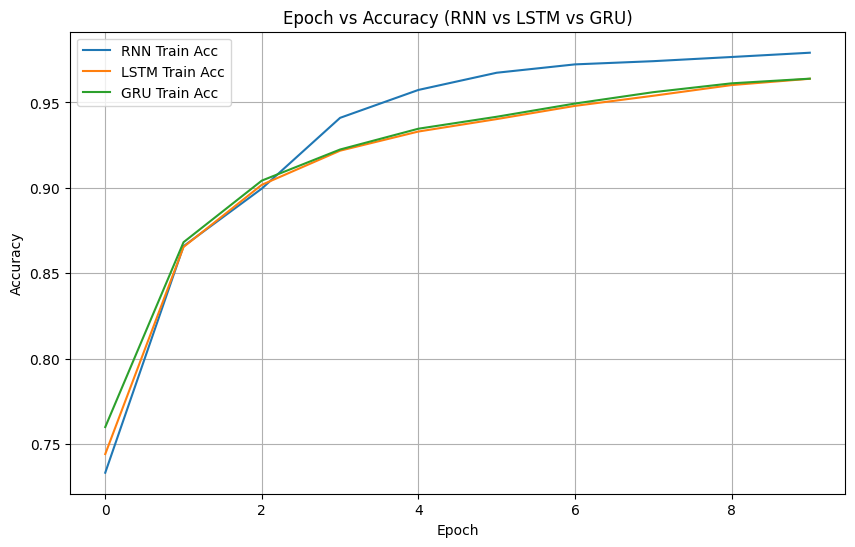

In [81]:
plt.figure(figsize=(10,6))

plt.plot(rnn_history.history['accuracy'], label="RNN Train Acc")
# plt.plot(rnn_history.history['val_accuracy'], label="RNN Val Acc")

plt.plot(lstm_history.history['accuracy'], label="LSTM Train Acc")
# plt.plot(lstm_history.history['val_accuracy'], label="LSTM Val Acc")

plt.plot(gru_history.history['accuracy'], label="GRU Train Acc")
# plt.plot(gru_history.history['val_accuracy'], label="GRU Val Acc")

plt.title("Epoch vs Accuracy (RNN vs LSTM vs GRU)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()